# $R^2$ versus slope $b$
Plot the 14 rounded values supplied by the user on 2026-10-02. Horizontal bars reproduce the supplied slope uncertainties; no uncertainty for $R^2$ was supplied. Lines connect points in increasing window $L$; no new fit is performed. Both axes use linear scales.

In [1]:
import os
CPU_RANGE=(40,41)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
print('Allocated CPUs:',selected)

Allocated CPUs: [40, 41]


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
OUT=Path.cwd()
data=[
(.1,.038,.010,.5890),(.2,.081,.012,.9312),(.3,.149,.011,.9647),
(.4,.165,.010,.9905),(.5,.230,.012,.9889),(.6,.307,.009,.9926),
(.7,.379,.011,.9983),(.8,.472,.008,.9977),(.9,.627,.009,.9983),
(.95,.779,.011,.9981),(.99,1.187,.013,.9997),(.999,1.745,.016,.9989),
(.9999,2.327,.018,.9991),(.99999,3.035,.022,.9979)]
df=pd.DataFrame(data,columns=['L','b','b_uncertainty','R_squared'])
df.to_csv(OUT/'plotted_data.csv',index=False)
display(df)

,L,b,b_uncertainty,R_squared
0,0.10000,0.038,0.010,0.5890
1,0.20000,0.081,0.012,0.9312
2,0.30000,0.149,0.011,0.9647
3,0.40000,0.165,0.010,0.9905
4,0.50000,0.230,0.012,0.9889
5,0.60000,0.307,0.009,0.9926
6,0.70000,0.379,0.011,0.9983
7,0.80000,0.472,0.008,0.9977
8,0.90000,0.627,0.009,0.9983
9,0.95000,0.779,0.011,0.9981


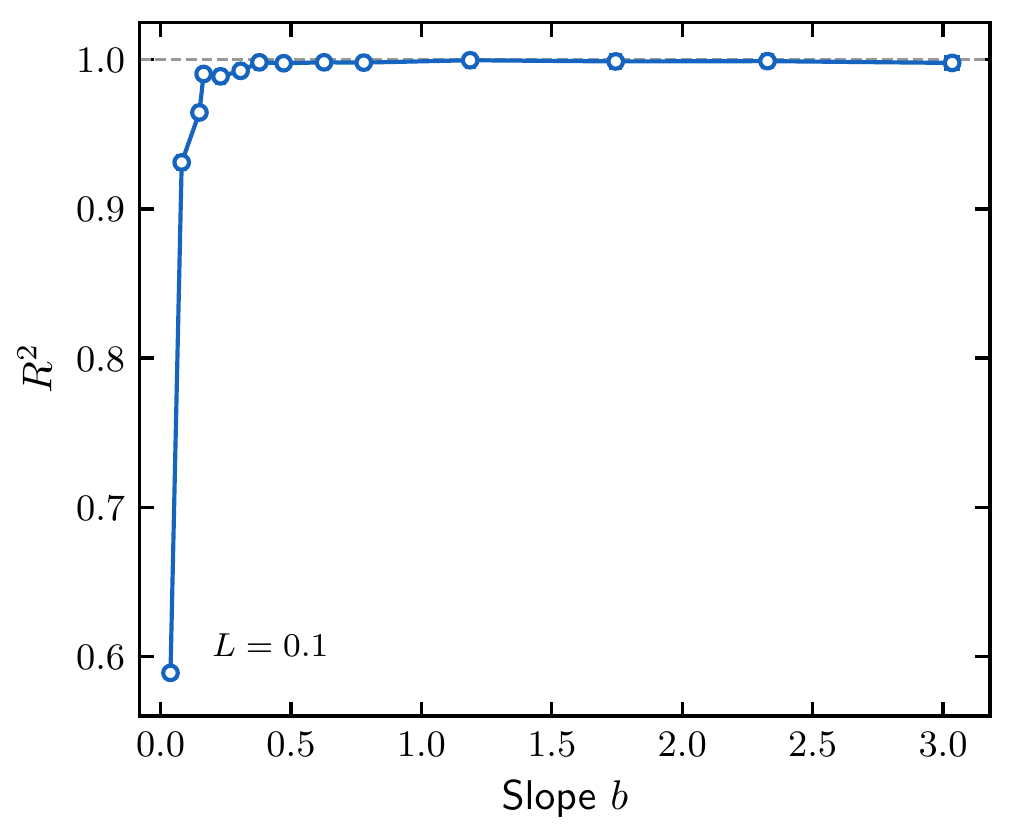

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import shutil,subprocess
from IPython.display import Image
root=next(parent for parent in OUT.parents if (parent/'PROJECT_ADMIN/REPO_POLICY.md').exists())
support=root/'00_WORKSPACE/CURRENT/final_production_new_designs/13_maxmix_manybody_lyapunov_4ny/analysis_outputs/modular_gap_window_slopes_v1/latex_support'
shutil.copytree(support,OUT/'latex_support',dirs_exist_ok=True)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':9,'axes.labelsize':10,'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}',
 'xtick.direction':'in','ytick.direction':'in','legend.frameon':False})
fig,ax=plt.subplots(figsize=(3.375,2.8))
ax.axhline(1,color='.6',ls='--',lw=.7)
ax.errorbar(df.b,df.R_squared,xerr=df.b_uncertainty,fmt='o-',color='#1565c0',
 mfc='white',ms=3.5,lw=1,capsize=2,elinewidth=.8)
ax.set(xlabel=r'Slope $b$',ylabel=r'$R^2$',xlim=(-.08,3.18),ylim=(.56,1.025))
ax.tick_params(top=True,right=True)
ax.annotate(r'$L=0.1$',(df.b.iloc[0],df.R_squared.iloc[0]),xytext=(10,4),
 textcoords='offset points',fontsize=8)
fig.tight_layout(pad=.6)
fig.savefig(OUT/'r_squared_vs_b.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'r_squared_vs_b.pdf'),str(OUT/'r_squared_vs_b')],check=True)
display(Image(filename=str(OUT/'r_squared_vs_b.png')))

In [4]:
assert len(df)==14 and np.isfinite(df.to_numpy()).all()
assert df.R_squared.between(0,1).all() and (df.b_uncertainty>0).all()
print('All 14 supplied rows plotted; horizontal uncertainties retained; no refitting.')

All 14 supplied rows plotted; horizontal uncertainties retained; no refitting.
